# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 03 — Los modelos generativos

**Objetivo.** Entrenar los generadores que producirán las ventanas sintéticas y —antes de
usarlos— **auditarlos**. El enunciado solo exige medir el efecto *downstream*, pero sin esta
auditoría un generador que mejore el modelo por puro efecto regularizador sería
indistinguible de otro que lo mejore por realismo, y son conclusiones opuestas.

### Qué se genera exactamente

Se modela la distribución **conjunta** del par `[X | y]` (60 retornos + target), no `X` por
separado. Es la opción **OPT2** de las transparencias del profesor: `z → Generador → (Xg, yg)`.
Un generador que solo produjera `X` obligaría a etiquetar después, y esa etiqueta sería
inventada por otro modelo — contaminando el experimento en su punto más sensible.

### Los seis generadores

| # | Generador | Familia | Papel |
|---|---|---|---|
| 1 | Jitter | trivial | el "modelo simple" que pide el enunciado |
| 2 | Gaussiana multivariante | paramétrico | captura toda la dependencia **lineal**; el rival honesto |
| 3 | Block bootstrap estacionario | remuestreo | preserva colas y clustering *por construcción* |
| 4 | **VAE** | latente variacional | red 1 |
| 5 | **Diffusion-TS R61** | difusión temporal | red 2 — target como token especial |
| 6 | **RealNVP** | flow biyectivo | red 3 — única con verosimilitud exacta |

Las tres familias neuronales cubren el requisito de "3 tipos distintos de modelo generativo";
las tres primeras son baselines que hacen la comparación honesta.

### Regla anti-fuga

Los generadores se ajustan **solo con el conjunto de train**. Ni validación ni test entran
jamás en un generador: si lo hicieran, los datos sintéticos transportarían información del
futuro al entrenamiento y todo el experimento quedaría invalidado.

## 0 · Setup

In [1]:
import sys, json, time, hashlib
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.generators import (JitterGenerator, GaussianGenerator, BlockBootstrapGenerator,
                            VAEGenerator, DiffusionTSR61Generator, RealNVPGenerator)
from src.gen_audit import audit_generator
from src.gen_utility import resumir_tstr, tstr_trtr
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
if device.type == "cpu":
    torch.set_num_threads(8)

d = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))

def to_XY(split):
    # Par conjunto [X | y] estandarizado con los estadísticos de train

    X = (d[f"X_{split}"] - std["x_mu"]) / std["x_sd"]
    y = (d[f"y_{split}"] - std["y_mu"]) / std["y_sd"]
    return np.column_stack([X, y]).astype(np.float32)

XY_train, XY_val = to_XY("train"), to_XY("val")
print("Device:", device, "| XY_train:", XY_train.shape, "| XY_val (solo auditoría):", XY_val.shape)

C:\Users\diego\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Device: cuda | XY_train: (102406, 61) | XY_val (solo auditoría): (17146, 61)


## 1 · Configuración de los generadores

Los hiperparámetros no salen de la nada: son el resultado de un ciclo de diagnóstico
documentado en §4. Dos merecen explicación explícita porque corrigen defectos reales que
aparecieron al auditar las primeras versiones:

* **VAE con ruido de observación.** El decoder devuelve `E[x|z]`, no una muestra de `p(x|z)`.
  Muestrear solo la media pierde el segundo término de
  `Var(x) = Var(E[x|z]) + E[Var(x|z)]`: las primeras muestras salían con desviación típica
  0,39 frente a 1,00 real. Reinyectamos la desviación residual estimada tras entrenar, que
  es exactamente el decoder gaussiano de varianza aprendida que el ELBO define.
* **Diffusion-TS sobre R61.** Recibe exactamente las mismas 61 variables estandarizadas que
  VAE y RealNVP. Los 60 retornos son tokens temporales y `y` es un token especial —no un
  retorno número 61—. Predice directamente el par limpio desde versiones ruidosas y suma
  una pérdida Fourier solo sobre X; evita el equilibrio adversarial del WGAN-GP retirado.
  Se usan 3.000 updates y 50 pasos DDIM, sin reescalado post hoc.

In [2]:
GENERADORES = {
    "jitter":          JitterGenerator(noise=0.10),
    "gaussiana":       GaussianGenerator(),
    "block_bootstrap": BlockBootstrapGenerator(mean_block=10),
    "vae":             VAEGenerator(latent=16, hidden=256, beta=1.0, epochs=40),
    "diffusion_ts":    DiffusionTSR61Generator(train_steps=3000, sample_steps=50),
    "realnvp":         RealNVPGenerator(n_layers=6, hidden=128, epochs=30),
}
NEURONALES = ["vae", "diffusion_ts", "realnvp"]

fitted, tiempos = {}, {}
for name, gen in GENERADORES.items():
    t0 = time.time()
    gen.fit(XY_train, seed=cfg.seed) if name in NEURONALES else gen.fit(XY_train)
    tiempos[name] = time.time() - t0
    fitted[name] = gen
    print(f"{name:16s} ajustado en {tiempos[name]:7.1f}s")

jitter           ajustado en     0.0s
gaussiana        ajustado en     0.0s
block_bootstrap  ajustado en     0.0s


vae              ajustado en    31.4s


diffusion_ts     ajustado en    55.4s


realnvp          ajustado en    70.2s


### 1.1 · Arquitectura de las tres familias neuronales

Antes de mirar sus curvas de loss, conviene ver qué son. Los tres diagramas se generan con
[PlotNeuralNet](https://github.com/HarisIqbal88/PlotNeuralNet) desde `src/netviz.py`, y —esto
es lo importante— **se derivan por introspección de los generadores que se acaban de
ajustar**, no de una descripción escrita a mano. A la celda se le pasa el diccionario
`fitted`, así que las cifras de cada figura son literalmente las de los objetos entrenados
en la celda anterior: si mañana se cambia `n_layers=6` por otro valor, el diagrama cambia
con él.

No es una precaución teórica. Las clases de `src/generators.py` traen por defecto
`RealNVPGenerator(n_layers=8, hidden=256)`, pero este notebook entrena con **6 capas y
hidden 128**; una figura dibujada "de memoria" a partir de la firma de la clase habría
inventado dos capas de acoplamiento inexistentes.

Lo que hay que leer en cada una:

* **VAE** — la bifurcación en μ y log σ² es la firma del modelo: el encoder no produce un
  código, produce una *distribución*. El cuello de 16 unidades frente a las 61 de entrada
  es el cuello de botella que fuerza el suavizado, y explica la curtosis 1,6 de §3.
* **Diffusion-TS R61** — proyección separada de retornos y target, Transformer
  bidireccional y cabezas de tendencia, Fourier y residuo. La atención aprende la
  distribución conjunta X–y sin recibir los 21 retornos futuros que originan el target.
* **RealNVP** — la cadena de acoplamientos con máscaras alternas par/impar. El detalle de
  abajo muestra por qué el jacobiano es triangular y su log-determinante, una simple suma:
  es lo que hace la verosimilitud exacta y barata.

  = 20_arq_vae: sin cambios, se reutiliza el PNG cacheado


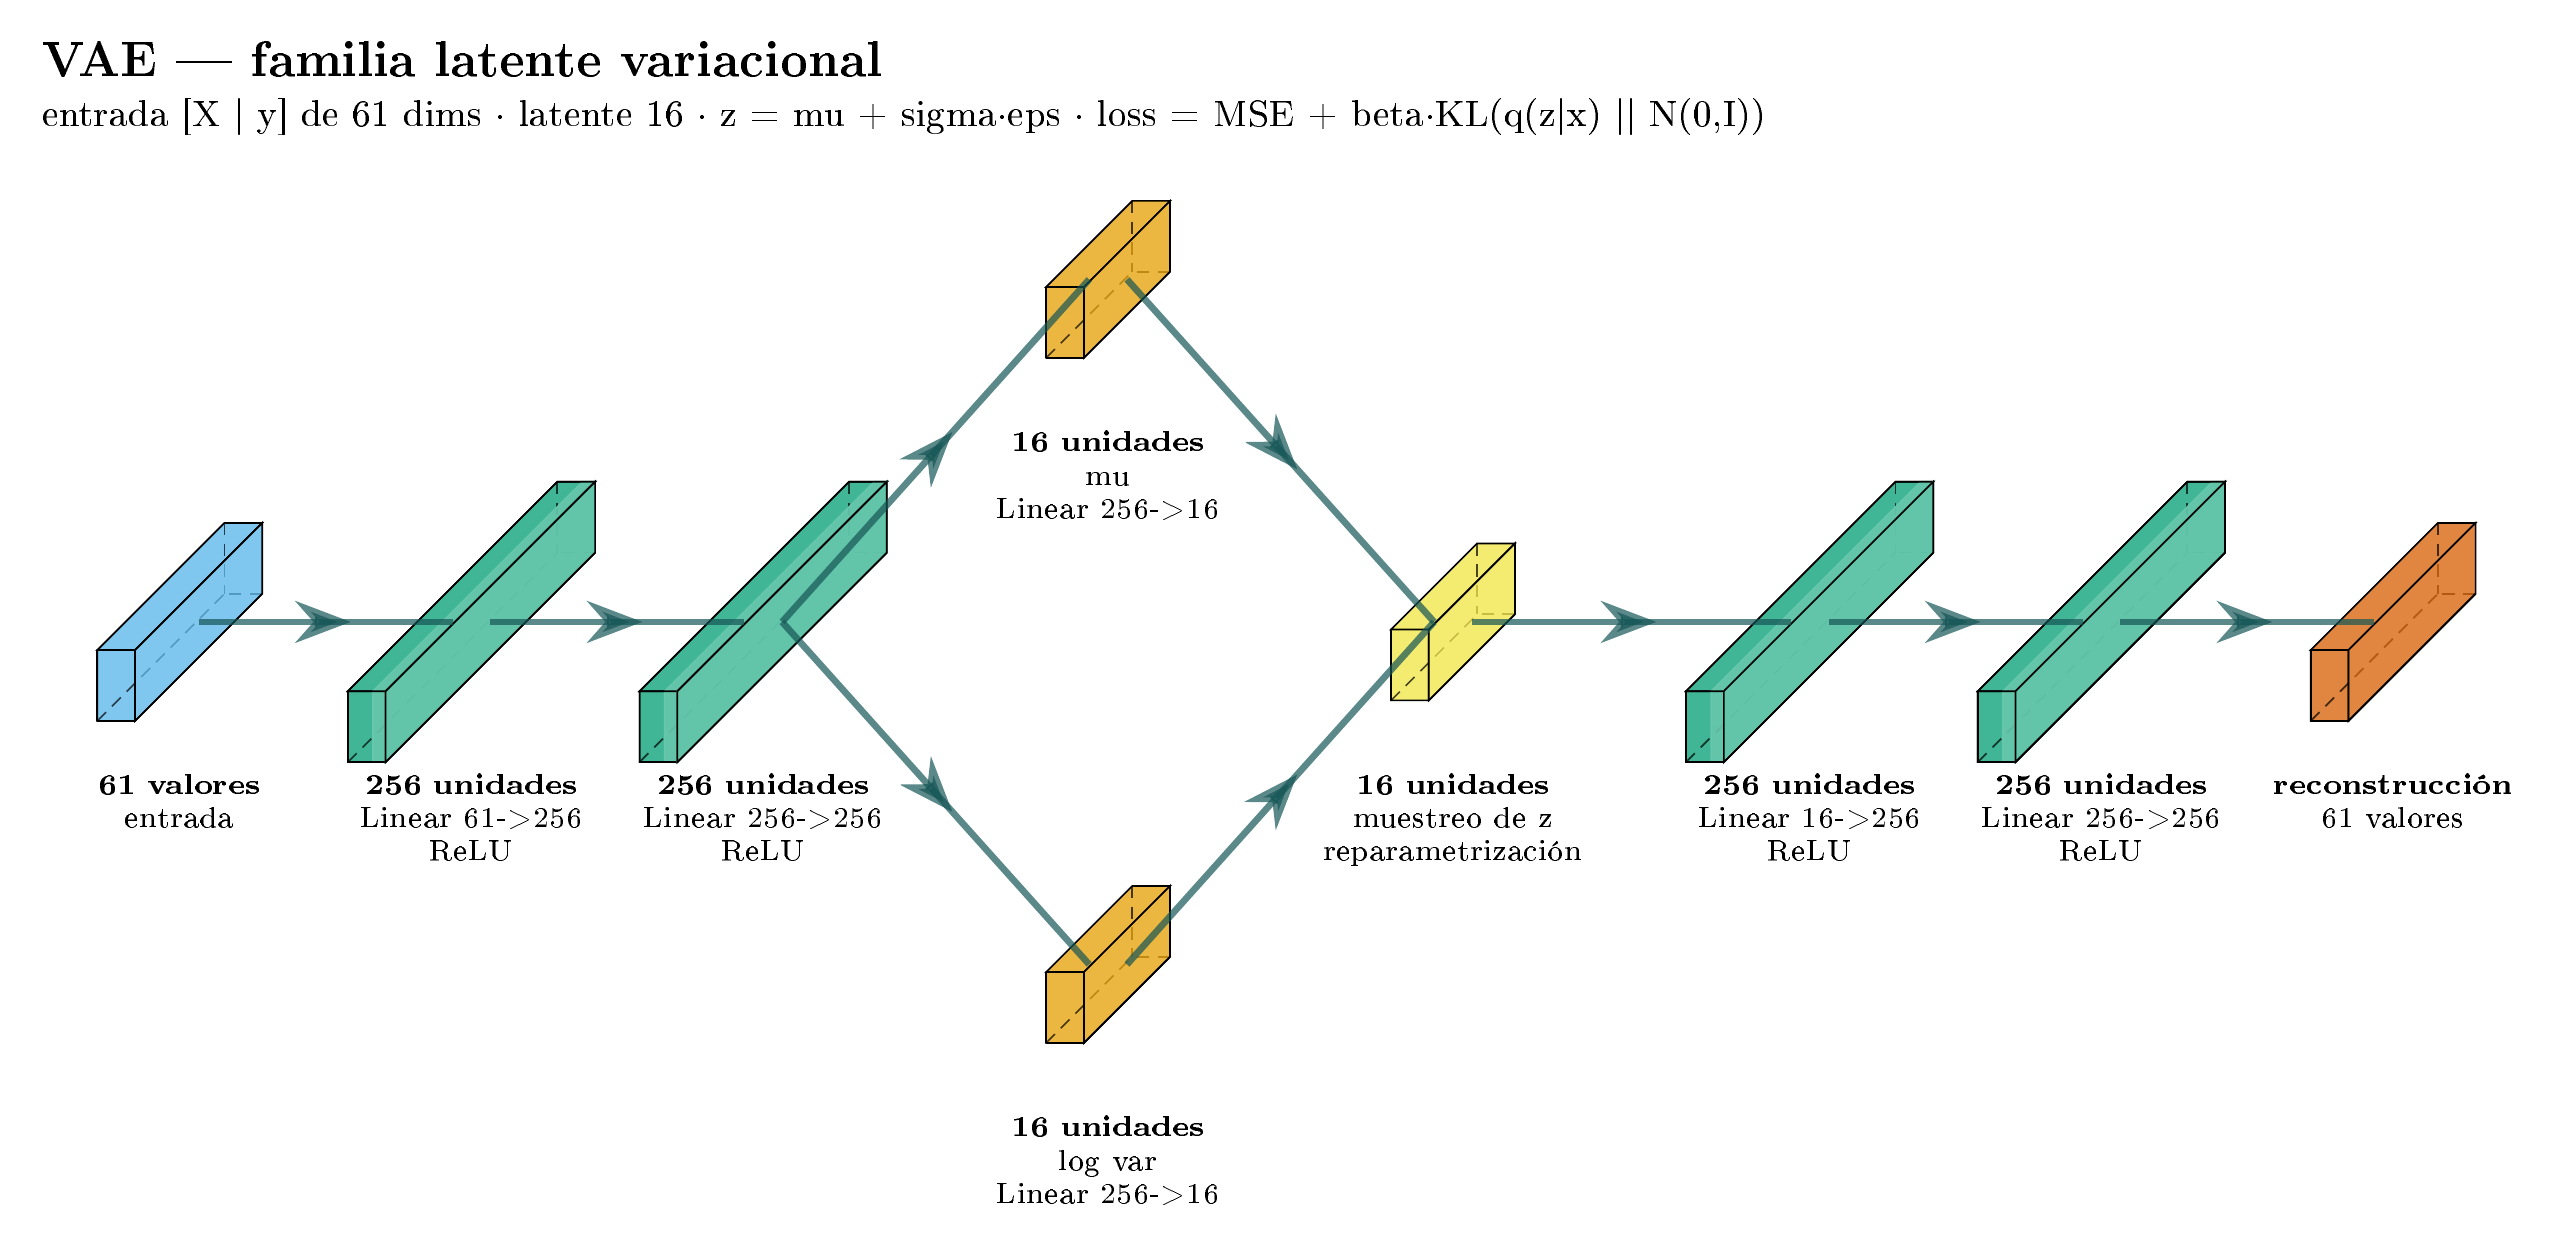

  ! 21_arq_diffusion_ts: sin pdflatex y sin PNG cacheado; figura omitida
  = 22_arq_realnvp: sin cambios, se reutiliza el PNG cacheado


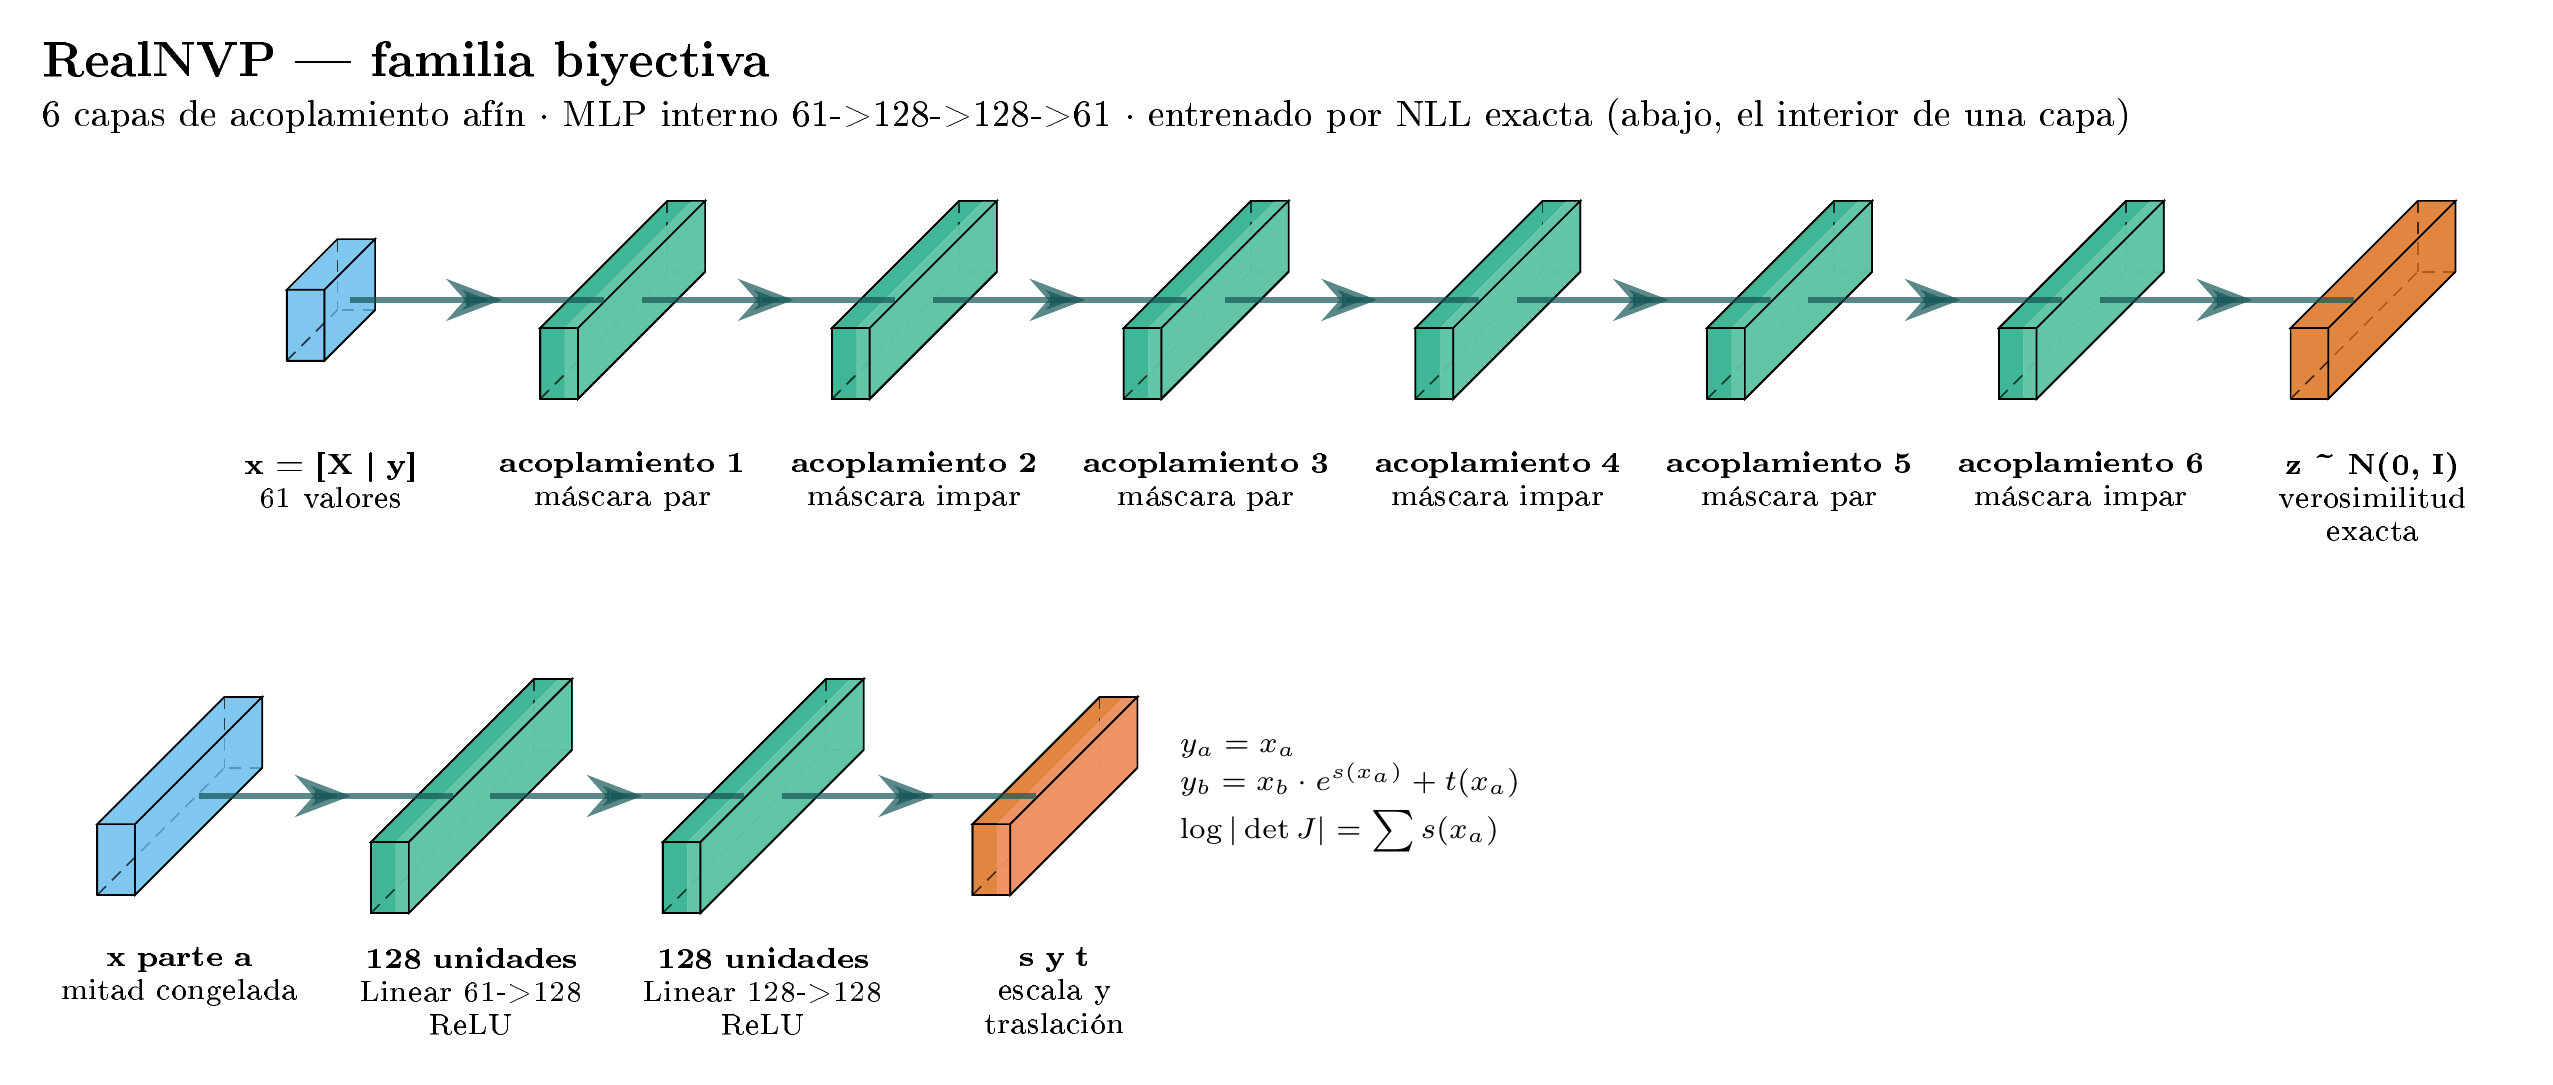

In [3]:
from IPython.display import Image, display

from src.netviz import diagramas_taller, render

# `fitted` son los generadores REALES recién entrenados: pasarlos garantiza que la
# figura describe lo que se ejecutó y no los valores por defecto de las clases.
# Las candidatas downstream (16-19) y el pipeline (23) se dibujan en el notebook 02.
DIAGRAMAS_03 = {"20", "21", "22"}

for diag in diagramas_taller(cfg, generadores=fitted):
    if diag.nombre[:2] not in DIAGRAMAS_03:
        continue
    png = render(diag, fig_dir=cfg.fig_dir)   # compila solo si el .tex cambió
    if png is not None:
        display(Image(filename=str(png), width=1000))

## 2 · Curvas de convergencia de los generadores

Requisito explícito del enunciado: *"para cada entrenamiento, incluir las curvas de loss
donde se vea que el modelo ha convergido"*. Los tres baselines no entrenan (no tienen
curva); las tres redes sí.

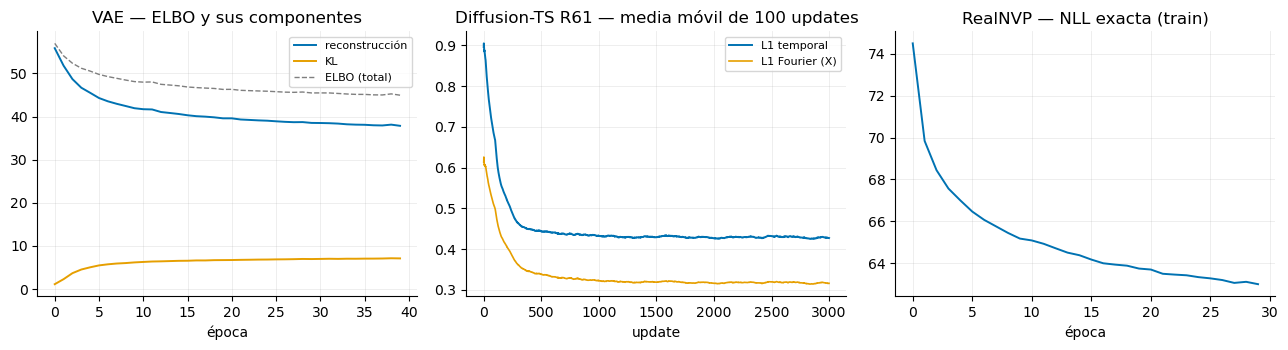

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# VAE: la loss total y sus dos componentes (reconstrucción y KL)
h = fitted["vae"].history_
axes[0].plot(h["recon"], color=PALETTE["blue"], lw=1.4, label="reconstrucción")
axes[0].plot(h["kl"], color=PALETTE["orange"], lw=1.4, label="KL")
axes[0].plot(h["loss"], color=PALETTE["grey"], lw=1.0, ls="--", label="ELBO (total)")
axes[0].set_title("VAE — ELBO y sus componentes"); axes[0].legend(fontsize=8)

# Diffusion-TS: pérdida temporal y componente espectral sobre los 60 retornos
h = fitted["diffusion_ts"].history_
w = 100
axes[1].plot(pd.Series(h["temporal"]).rolling(w, min_periods=1).mean(),
             color=PALETTE["blue"], lw=1.4, label="L1 temporal")
axes[1].plot(pd.Series(h["spectral"]).rolling(w, min_periods=1).mean(),
             color=PALETTE["orange"], lw=1.2, label="L1 Fourier (X)")
axes[1].set_title("Diffusion-TS R61 — media móvil de 100 updates")
axes[1].legend(fontsize=8)

# RealNVP: NLL exacta sobre train
h = fitted["realnvp"].history_
axes[2].plot(h["nll"], color=PALETTE["blue"], lw=1.4)
axes[2].set_title("RealNVP — NLL exacta (train)")

for i, ax in enumerate(axes):
    ax.set_xlabel("update" if i == 1 else "época"); _style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "11_convergencia_generadores.png", dpi=120, bbox_inches="tight")

In [5]:
# Prueba numérica de convergencia: cola suavizada para la difusión estocástica
conv = []
for name in NEURONALES:
    h = fitted[name].history_
    key = {"vae": "loss", "diffusion_ts": "loss", "realnvp": "nll"}[name]
    cola = 100 if name == "diffusion_ts" else 10
    v = np.array(h[key])[-cola:]
    conv.append({"generador": name, "métrica": key,
                 "valor_final": v[-1],
                 "max/min_ult10": v.max() / v.min() if v.min() > 0 else np.nan,
                 "pendiente_ult10": np.polyfit(np.arange(len(v)), v, 1)[0]})
pd.DataFrame(conv).set_index("generador").round(4)

,métrica,valor_final,max/min_ult10,pendiente_ult10
generador,,,,
vae,loss,44.9591,1.0118,-0.0523
diffusion_ts,loss,0.4627,1.1923,0.0000
realnvp,nll,63.0014,1.0111,-0.0709


**Lectura.** El VAE y el RealNVP exhiben la convergencia limpia esperable de una
maximización de verosimilitud. Diffusion-TS optimiza minibatches y timesteps ruidosos: su
loss instantánea no es monótona, pero la media móvil de 100 updates desciende y se
estabiliza. La curva prueba optimización estable; la fidelidad y la utilidad se deciden en
las auditorías siguientes, no por la loss de train.

## 3 · Auditoría de fidelidad: ¿se parecen las ventanas sintéticas a las reales?

> **El marco de esta auditoría.** La literatura de datos sintéticos evalúa un generador en
> tres ejes: **fidelidad** (¿reproduce la distribución?), **utilidad** (¿sirve para entrenar
> el modelo final?) y **privacidad** (¿ha memorizado registros del entrenamiento?). Esta
> sección cubre el primero y la §4 el segundo. La **privacidad queda fuera del alcance del
> taller**: los datos de partida son precios de mercado públicos, no registros personales, de
> modo que no hay secreto que filtrar — pero conviene declararlo, porque en un caso de uso con
> datos de clientes esa tercera auditoría sería obligatoria y su ausencia, descalificante.

Dos familias de métricas. Las primeras son los hechos estilizados del notebook 01 — los
que una gaussiana no puede capturar por construcción:

| Métrica | Qué mide | Referencia |
|---|---|---|
| curtosis en exceso | colas gruesas | la real (≈ 24) |
| ACF de \|r\| | clustering de volatilidad | la real (≈ 0,06 a lag 1) |
| corr(r_t, \|r_{t+k}\|) | efecto apalancamiento | la real (negativa) |
| error de corr(X, y) | ¿preserva la relación que el downstream debe aprender? | 0 = perfecto |
| **discriminative AUC** | ¿un clasificador distingue real de sintético? | **0,5 = indistinguible** |

Las segundas cuantifican lo que hasta ahora solo se veía **a ojo** en el histograma, y
añaden el eje que faltaba por completo — la dependencia **entre las posiciones de la
ventana**:

| Métrica | Qué mide | Referencia |
|---|---|---|
| **KS** de los retornos | máxima separación entre las ECDF; sensible al **cuerpo** | 0 = idénticas |
| **Wasserstein-1** | área entre las ECDF; pondera cuánto se desplaza cada cuantil, así que acusa las **colas** | 0 = idénticas |
| KS / W1 columna a columna | desajustes que se cancelan al agrupar los 60 retornos | 0 = idénticas |
| **err. corr(X,X) Pearson** | distancia entre las matrices de correlación 60×60 | 0 = perfecto |
| **err. corr(X,X) Spearman** | lo mismo en **rangos**: dependencia monótona no lineal | 0 = perfecto |

> **Por qué KS y Wasserstein juntos, y no uno solo.** KS se satura: en cuanto las ECDF se
> separan en el cuerpo, da casi lo mismo lo que pase en la cola, donde queda poca masa. W1
> integra la distancia horizontal entre cuantiles, así que un cuantil del 0,1 % que se queda
> corto en 5σ sí pesa. Un generador con KS bajo y W1 alto acierta la forma central y falla
> los extremos — exactamente la patología que este taller persigue.
>
> **Y por qué el estadístico de KS y no su p-valor.** Con n ≈ 480.000 el p-valor es 0 para
> cualquier diferencia, por minúscula que sea: el test siempre "rechaza" y no informa de
> nada. El estadístico, acotado en [0, 1], sí es un tamaño del efecto comparable entre
> generadores.

In [6]:
N_AUDIT = 8000
rng = np.random.default_rng(cfg.seed)
real_ref = XY_train[rng.choice(len(XY_train), N_AUDIT, replace=False)]

# `muestras` se reutiliza en las figuras de §3.3: así los gráficos describen
# exactamente el mismo lote que la tabla, y no otro sorteo del generador.
auditoria, muestras = {}, {}
for name, gen in fitted.items():
    muestras[name] = gen.sample(N_AUDIT, seed=cfg.seed + 1)
    auditoria[name] = audit_generator(real_ref, muestras[name], seed=cfg.seed)

aud = pd.DataFrame(auditoria).T
ref = aud.iloc[0][["sd_x_real", "curtosis_x_real", "asimetria_x_real", "sd_y_real",
                   "acf_abs_lag1_real", "acf_abs_lag21_real", "leverage_lag1_real"]]
print("REFERENCIA REAL:", {k.replace("_real", ""): round(float(v), 3) for k, v in ref.items()})

HECHOS = ["sd_x", "curtosis_x", "asimetria_x", "sd_y", "acf_abs_lag1", "acf_abs_lag21",
          "leverage_lag1", "err_corr_xy", "discriminative_auc"]
DISTANCIAS = ["ks_x", "w1_x", "ks_x_col_media", "w1_x_col_media", "ks_y", "w1_y",
              "err_corr_xx_pearson", "err_corr_xx_spearman", "discriminative_auc"]

print("\nHechos estilizados (comparar con la referencia real de arriba):")
display(aud[HECHOS].round(3))
print("Distancias distribucionales y dependencia X-X (0 = perfecto en todas):")
display(aud[DISTANCIAS].round(4))

C:\Users\diego\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\diego\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\diego\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\diego\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^

REFERENCIA REAL: {'sd_x': 1.003, 'curtosis_x': 25.235, 'asimetria_x': -0.538, 'sd_y': 0.988, 'acf_abs_lag1': 0.062, 'acf_abs_lag21': -0.016, 'leverage_lag1': -0.025}

Hechos estilizados (comparar con la referencia real de arriba):


,sd_x,curtosis_x,asimetria_x,sd_y,acf_abs_lag1,acf_abs_lag21,leverage_lag1,err_corr_xy,discriminative_auc
jitter,1.000,23.565,-0.554,1.003,0.058,-0.018,-0.021,0.014,0.507
gaussiana,1.001,0.031,-0.009,0.992,-0.015,-0.010,0.002,0.013,0.958
block_bootstrap,0.990,26.161,-0.513,1.014,0.125,-0.027,-0.018,0.042,0.760
vae,0.909,1.502,-0.189,0.989,-0.005,-0.012,-0.004,0.028,0.900
diffusion_ts,0.693,20.322,-0.221,0.811,-0.013,-0.011,-0.001,0.036,0.784
realnvp,0.940,22.483,-0.100,0.968,0.042,-0.020,-0.014,0.025,0.662


Distancias distribucionales y dependencia X-X (0 = perfecto en todas):


,ks_x,w1_x,ks_x_col_media,w1_x_col_media,ks_y,w1_y,err_corr_xx_pearson,err_corr_xx_spearman,discriminative_auc
jitter,0.0100,0.0125,0.0141,0.0257,0.0199,0.0305,0.0248,0.0162,0.5068
gaussiana,0.0928,0.2386,0.0998,0.2359,0.0371,0.0957,0.0201,0.0397,0.9583
block_bootstrap,0.0059,0.0103,0.0281,0.0568,0.0072,0.0139,0.0538,0.0323,0.7605
vae,0.0664,0.1556,0.0744,0.1569,0.0441,0.0987,0.0493,0.0267,0.8998
diffusion_ts,0.0683,0.1869,0.0811,0.1873,0.1654,0.3257,0.0566,0.0336,0.7840
realnvp,0.0142,0.0270,0.0279,0.0543,0.0359,0.1017,0.0418,0.0237,0.6622


### 3.1 Comparación visual de marginales

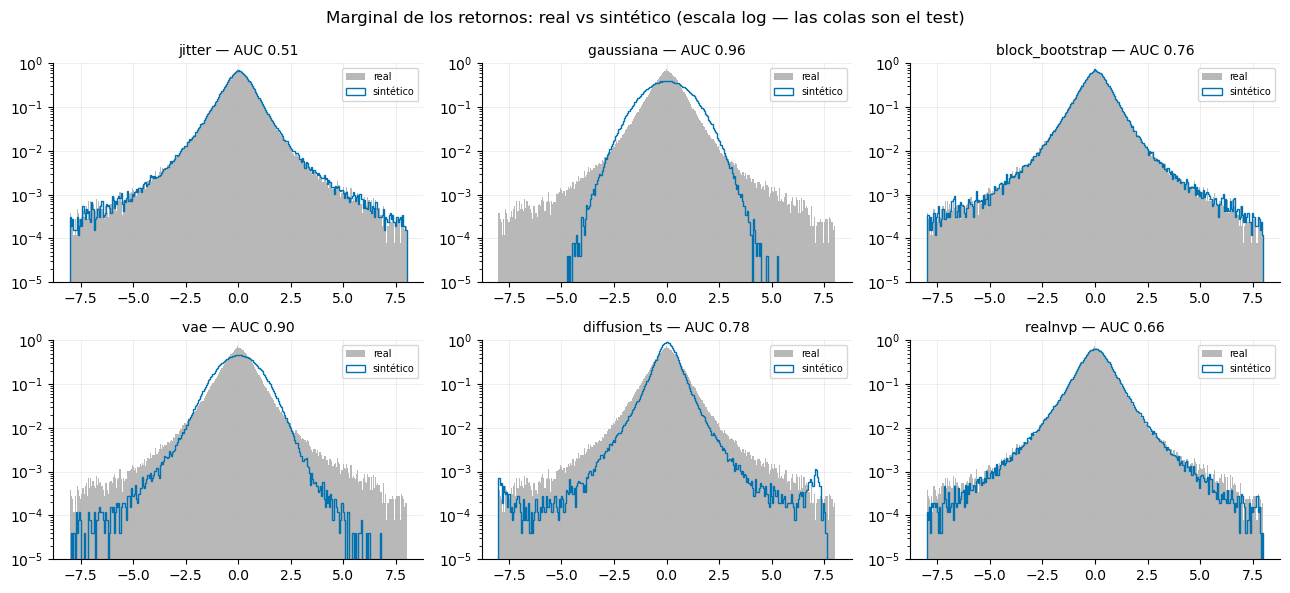

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
xs = np.linspace(-8, 8, 300)
for ax, (name, gen) in zip(axes.ravel(), fitted.items()):
    s = gen.sample(N_AUDIT, seed=cfg.seed + 1)[:, :-1].ravel()
    ax.hist(real_ref[:, :-1].ravel(), bins=300, range=(-8, 8), density=True,
            color=PALETTE["grey"], alpha=0.55, label="real")
    ax.hist(s, bins=300, range=(-8, 8), density=True,
            histtype="step", color=PALETTE["blue"], lw=1.2, label="sintético")
    ax.set_yscale("log"); ax.set_ylim(1e-5, 1)
    ax.set_title(f"{name} — AUC {auditoria[name]['discriminative_auc']:.2f}", fontsize=10)
    ax.legend(fontsize=7)
    _style(ax)
fig.suptitle("Marginal de los retornos: real vs sintético (escala log — las colas son el test)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "12_marginales_generadores.png", dpi=120, bbox_inches="tight")

### 3.3 Q-Q y colas: dónde exactamente se rompe cada generador

Los números de la tabla dicen *cuánto* se desvía cada generador; estas dos figuras dicen
**dónde**. Son el complemento natural del histograma de §3.2, que en escala logarítmica ya
insinúa el problema pero no permite leer cuantil a cuantil.

* **Q-Q de dos muestras (figura 24).** Cuantiles reales en el eje x, sintéticos en el y. Si
  las distribuciones coinciden, los puntos caen sobre la diagonal. Lo informativo son los
  extremos: una curva que **se aplana** al alejarse del centro es un generador cuyas colas
  se quedan cortas — no puede producir el suceso que el mercado sí produce.
* **Supervivencia de \|r\| en log-log (figura 25).** `P(|r| > x)` frente a `x`. Las colas de
  los retornos siguen aproximadamente una ley de potencias, que en estos ejes es una
  **recta**. Un generador que gaussianiza se despeña; uno que reproduce las colas acompaña a
  la curva real hasta el final.

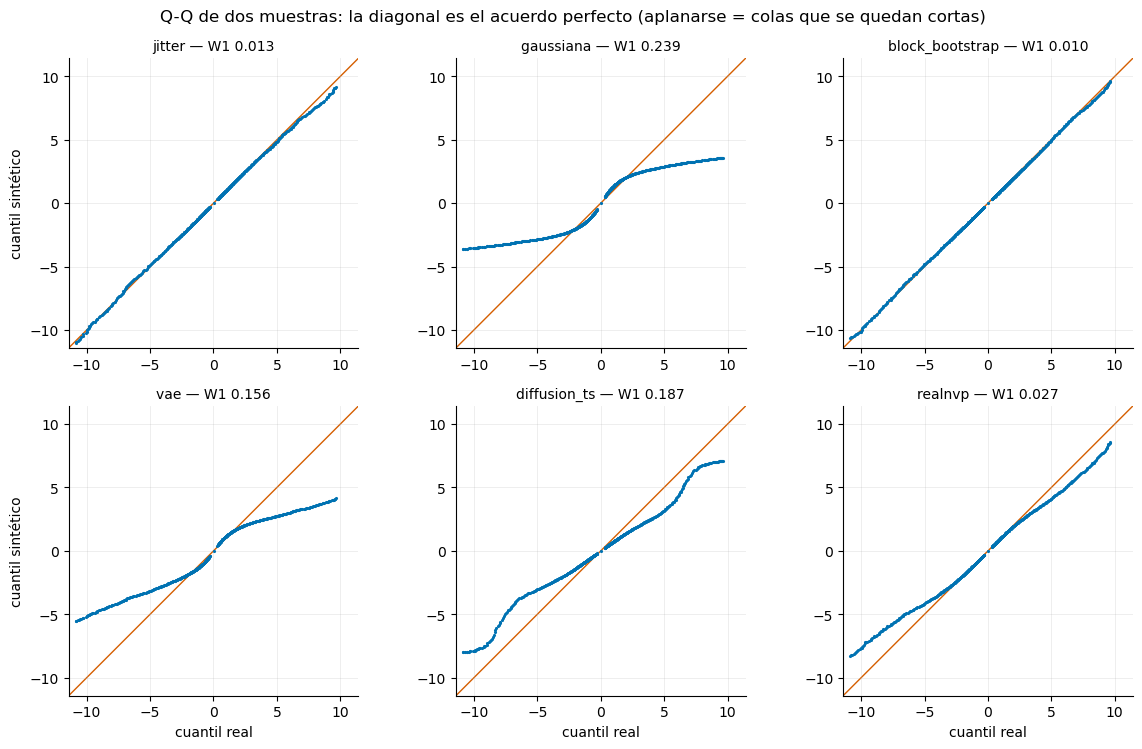

In [8]:
# Rejilla de cuantiles densa en los extremos: es donde se decide la comparación
P = np.concatenate([np.logspace(-3.7, -0.5, 220),
                    [0.5],
                    1 - np.logspace(-0.5, -3.7, 220)])
retornos_real = real_ref[:, :-1].ravel()
q_real = np.quantile(retornos_real, P)
lim = np.abs(q_real).max() * 1.05

fig, axes = plt.subplots(2, 3, figsize=(12, 7.6))
for ax, (name, s) in zip(axes.ravel(), muestras.items()):
    q_synth = np.quantile(s[:, :-1].ravel(), P)
    ax.plot([-lim, lim], [-lim, lim], color=PALETTE["vermillion"], lw=1, zorder=1)
    ax.plot(q_real, q_synth, ".", ms=2.5, color=PALETTE["blue"], zorder=2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(f"{name} — W1 {auditoria[name]['w1_x']:.3f}", fontsize=10)
    _style(ax)
for ax in axes[1]:
    ax.set_xlabel("cuantil real")
for ax in axes[:, 0]:
    ax.set_ylabel("cuantil sintético")
fig.suptitle("Q-Q de dos muestras: la diagonal es el acuerdo perfecto "
             "(aplanarse = colas que se quedan cortas)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "24_qq_generadores.png", dpi=120, bbox_inches="tight")

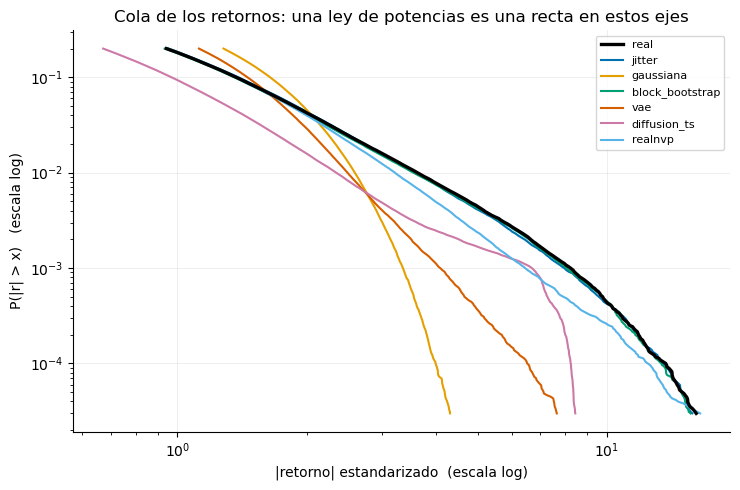

In [9]:
# Cola superior: P(|r| > x) sobre una rejilla logarítmica de probabilidades
P_COLA = np.logspace(np.log10(3e-5), np.log10(0.2), 220)

def supervivencia(x):
    """Umbral x tal que P(|r| > x) = p, para cada p de la rejilla."""
    return np.quantile(np.abs(x), 1 - P_COLA)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(supervivencia(retornos_real), P_COLA, color="black", lw=2.4,
        label="real", zorder=5)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
for col, (name, s) in zip(colores, muestras.items()):
    ax.plot(supervivencia(s[:, :-1].ravel()), P_COLA, color=col, lw=1.5, label=name)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("|retorno| estandarizado  (escala log)")
ax.set_ylabel("P(|r| > x)   (escala log)")
ax.set_title("Cola de los retornos: una ley de potencias es una recta en estos ejes")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "25_ecdf_colas.png", dpi=120, bbox_inches="tight")

### 3.4 Ventanas sintéticas, a ojo

El mismo formato que la figura 08 del notebook 01, para comparar directamente con las
ventanas reales.

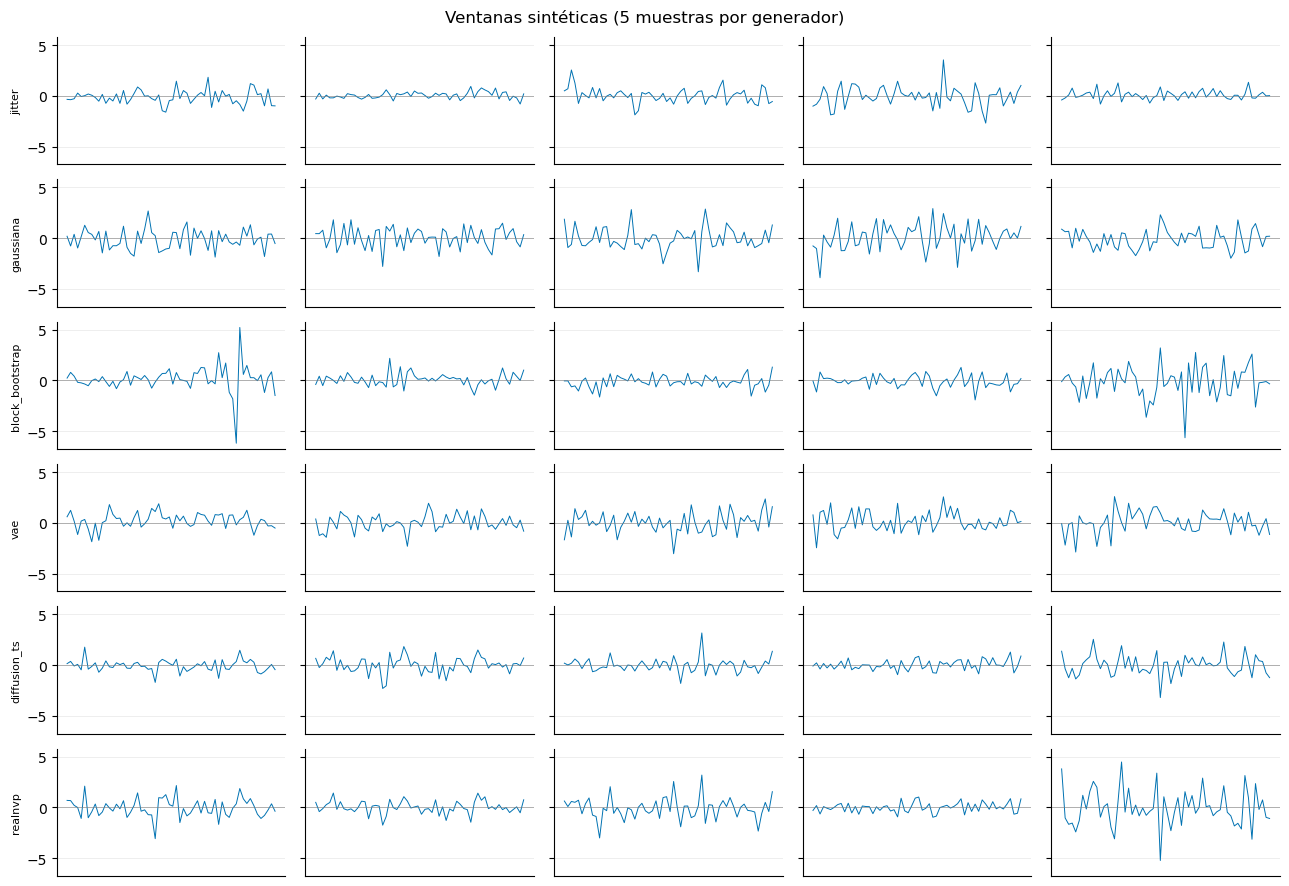

In [10]:
fig, axes = plt.subplots(len(fitted), 5, figsize=(13, 1.5 * len(fitted)), sharey=True)
for row, (name, gen) in enumerate(fitted.items()):
    s = gen.sample(5, seed=cfg.seed + 7)
    for col in range(5):
        ax = axes[row, col]
        ax.plot(s[col, :-1], lw=0.7, color=PALETTE["blue"])
        ax.axhline(0, color=PALETTE["grey"], lw=0.4)
        ax.set_xticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        _style(ax)
fig.suptitle("Ventanas sintéticas (5 muestras por generador)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "13_ventanas_sinteticas.png", dpi=120, bbox_inches="tight")

### 3.5 Verosimilitud exacta sobre datos reales no vistos

El RealNVP es el **único** generador del taller que puede responder "¿cómo de probable es
un dato real que nunca he visto bajo mi modelo?". Lo comparamos contra el listón trivial:
una normal estándar.

> **Cuidado con la referencia.** Es tentador usar la *entropía* de N(0, I),
> −D/2·log(2πe) ≈ −86,6, como listón. Sería un error: esa cifra es la verosimilitud que la
> gaussiana asigna a datos que **ya son** N(0, I). Las ventanas de validación están
> estandarizadas con los estadísticos de *train* y tienen mayor varianza (1,15 frente a
> 1,00), porque pertenecen a un régimen de volatilidad más alto. La referencia correcta es
> evaluar N(0, I) **sobre los mismos datos** con los que evaluamos el flow.

In [11]:
flow = fitted["realnvp"]
D = XY_train.shape[1]

def ll_normal_estandar(XY):
    """log N(x; 0, I) medio evaluada SOBRE los datos dados.

    Ojo con el error fácil: la *entropía* de N(0,I), -D/2·log(2πe), es la
    verosimilitud que esa gaussiana asigna a datos que ya son N(0,I). No
    sirve como referencia para validación, cuyas ventanas están
    estandarizadas con los estadísticos de TRAIN y tienen mayor varianza
    (régimen de volatilidad más alto). La referencia honesta es evaluar
    N(0,I) sobre los mismos datos que evaluamos con el flow.
    """
    return float(np.mean(-0.5 * (XY ** 2).sum(1) - 0.5 * D * np.log(2 * np.pi)))

tabla_ll = pd.DataFrame({
    "RealNVP": {"train": flow.log_likelihood(real_ref),
                "val (no vista)": flow.log_likelihood(XY_val)},
    "N(0, I) de referencia": {"train": ll_normal_estandar(real_ref),
                              "val (no vista)": ll_normal_estandar(XY_val)},
})
tabla_ll["ventaja del flow"] = tabla_ll["RealNVP"] - tabla_ll["N(0, I) de referencia"]
tabla_ll.round(2)

,RealNVP,"N(0, I) de referencia",ventaja del flow
train,-62.79,-86.71,23.92
val (no vista),-87.09,-91.64,4.56


## 4 · Auditoría de utilidad: TSTR frente a TRTR

La §3 responde "¿se **parecen** al dato real?". Falta la otra mitad del marco: **"¿sirven
para entrenar?"**. Son preguntas distintas y pueden dar respuestas opuestas — el jitter es
casi indistinguible del dato real (AUC 0,51) y, sin embargo, no aporta ni una configuración
que no estuviera ya en train.

    TSTR   Train on Synthetic, Test on Real
    TRTR   Train on Real,      Test on Real     (la referencia)

El número que resume la utilidad es el **ratio R²_TSTR / R²_TRTR**: 1,0 significa que el
dataset sintético conserva *toda* la información que el modelo necesita; 0, que no conserva
ninguna; negativo, que además introduce sesgo.

### Por qué esto va aquí y no en la malla del notebook 04

La malla responde una pregunta más rica —cuánto añade el sintético **sobre** N ventanas
reales— y por eso su mezcla de entrenamiento **siempre** incluye el bloque real. Nunca
entrena con 0 % de datos reales, así que el TSTR no cabe en ella. Y es una propiedad **del
generador**, no del régimen de escasez: su sitio es este notebook.

### Las tres reglas que hacen interpretable el ratio

| Regla | Por qué |
|---|---|
| **Presupuesto idéntico en ambos brazos** | 102.406 ventanas cada uno. Si un brazo tuviera menos datos, el ratio mezclaría utilidad con tamaño de muestra. |
| **El brazo TSTR no ve un solo dato real** | Ni siquiera para elegir la época. Cada brazo aparta un 10 % **de su propio material** con ese fin; si el sintético eligiera época mirando datos reales, el dato real habría entrado por la puerta de atrás. |
| **Arquitectura e hiperparámetros congelados** | Los mismos de `downstream_reference.json`. Si un brazo rinde distinto, la única explicación posible son los datos. |

> **Se evalúa sobre validación, no sobre test.** Comparar generadores es selección de
> modelo, y el test se reserva intacto para el resultado final del notebook 04. Es el mismo
> criterio de §3.5 con la verosimilitud del flow.

**Limitación que hay que declarar.** Los generadores **no se reajustan** en cada semilla: se
reutilizan los de §1, que costaron ~1 h de CPU. La dispersión que se mide es la del muestreo
sintético más la del entrenamiento downstream, no la del ajuste del generador — la misma
convención que el notebook 02, donde solo varía la semilla de entrenamiento.

In [12]:
REF_DOWN = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
RUTA_TSTR = cfg.out_dir / "tstr_nb03.csv"
RUTA_MANIFEST = cfg.out_dir / "tstr_nb03_manifest.json"
SEEDS_TSTR = (42, 43, 44)          # las mismas del notebook 02

print(f"Arquitectura congelada: {REF_DOWN['arch']} {REF_DOWN['arch_kwargs']}")
print(f"Entrenamiento congelado: {REF_DOWN['train_kwargs']}")
print(f"{(len(fitted) + 1) * len(SEEDS_TSTR)} entrenamientos "
      f"({len(fitted)} generadores + referencia real) × {len(SEEDS_TSTR)} semillas")

# El sidecar R61 guarda un manifiesto con receta downstream y configuración.
# Solo se reutiliza si están las 21 filas activas y todo coincide.
canon = json.dumps({"arch": REF_DOWN["arch"], "arch_kwargs": REF_DOWN["arch_kwargs"],
                    "train_kwargs": REF_DOWN["train_kwargs"]}, sort_keys=True)
receta = hashlib.sha1(canon.encode()).hexdigest()[:8]
esperados = {"real", *fitted.keys()}
cache_ok = False
if RUTA_TSTR.exists() and RUTA_MANIFEST.exists():
    manifest = json.load(open(RUTA_MANIFEST))
    previo = pd.read_csv(RUTA_TSTR)
    cache_ok = (manifest.get("complete") and manifest.get("downstream_recipe") == receta
                and manifest.get("train_steps") == fitted["diffusion_ts"].cfg["train_steps"]
                and manifest.get("sample_steps") == fitted["diffusion_ts"].cfg["sample_steps"]
                and set(previo.brazo) == esperados and len(previo) == 21
                and (previo.groupby("brazo").seed.nunique() == 3).all())
if cache_ok:
    tstr = previo
    print("TSTR oficial cargado: manifiesto y 21/21 filas validados")
else:
    tstr = tstr_trtr(fitted, XY_train, XY_val[:, :-1], d["y_val"],
                     ref=REF_DOWN, std=std, device=device,
                     seeds=SEEDS_TSTR, ruta_csv=None)
    tstr.to_csv(RUTA_TSTR, index=False)

Arquitectura congelada: gru {'hidden': 72, 'layers': 3, 'fc': 72}
Entrenamiento congelado: {'epochs': 100, 'batch_size': 1024, 'lr': 0.001, 'weight_decay': 1e-05, 'patience': 100, 'grad_clip': 1.0, 'cosine': True}
21 entrenamientos (6 generadores + referencia real) × 3 semillas
TSTR oficial cargado: manifiesto y 21/21 filas validados


In [13]:
res_tstr = resumir_tstr(tstr)
res_tstr[["brazo", "val_r2_media", "val_r2_sd", "ratio_tstr_trtr", "epoca_mejor"]].round(4)

,brazo,val_r2_media,val_r2_sd,ratio_tstr_trtr,epoca_mejor
0,real,0.5039,0.0085,1.0000,54.6667
1,diffusion_ts,0.4773,0.0033,0.9472,66.3333
2,realnvp,0.4771,0.0104,0.9467,64.6667
3,jitter,0.4653,0.0067,0.9233,92.0000
4,vae,0.3343,0.0077,0.6633,61.0000
5,block_bootstrap,0.3143,0.0056,0.6237,34.6667
6,gaussiana,-0.1953,0.0243,-0.3876,73.0000


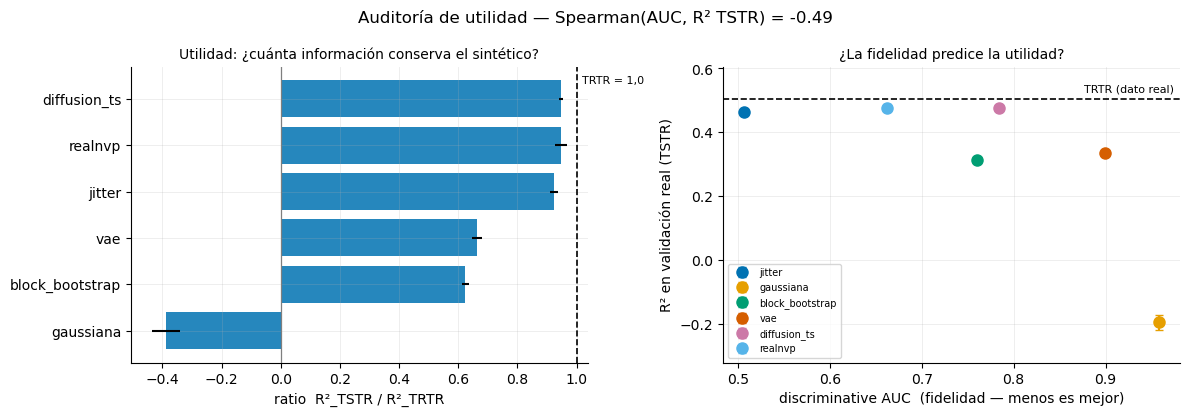

In [14]:
# Utilidad frente a fidelidad: ¿predice el discriminative AUC la utilidad real?
u = res_tstr.set_index("brazo")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]

orden = u.drop(index="real").sort_values("val_r2_media")
axes[0].barh(orden.index, orden.ratio_tstr_trtr,
             xerr=orden.val_r2_sd / u.loc["real", "val_r2_media"],
             color=PALETTE["blue"], alpha=0.85)
axes[0].axvline(1.0, color="black", lw=1.2, ls="--")
axes[0].axvline(0, color=PALETTE["grey"], lw=0.9)
# Ancladas con "axes fraction" en el eje y: la etiqueta no se sale de la figura
# aunque cambien el número de barras o el rango del eje.
axes[0].annotate("TRTR = 1,0", xy=(1.0, 1.0), xycoords=("data", "axes fraction"),
                 xytext=(4, -12), textcoords="offset points", fontsize=8)
axes[0].set_xlabel("ratio  R²_TSTR / R²_TRTR")
axes[0].set_title("Utilidad: ¿cuánta información conserva el sintético?", fontsize=10)
_style(axes[0])

for col, name in zip(colores, fitted):
    axes[1].errorbar(aud.loc[name, "discriminative_auc"], u.loc[name, "val_r2_media"],
                     yerr=u.loc[name, "val_r2_sd"], fmt="o", ms=8, color=col,
                     capsize=3, label=name)
axes[1].axhline(u.loc["real", "val_r2_media"], color="black", ls="--", lw=1.2)
axes[1].annotate("TRTR (dato real)", xy=(1.0, u.loc["real", "val_r2_media"]),
                 xycoords=("axes fraction", "data"), xytext=(-4, 5),
                 textcoords="offset points", fontsize=8, ha="right")
axes[1].margins(y=0.14)
axes[1].set_xlabel("discriminative AUC  (fidelidad — menos es mejor)")
axes[1].set_ylabel("R² en validación real (TSTR)")
axes[1].set_title("¿La fidelidad predice la utilidad?", fontsize=10)
axes[1].legend(fontsize=7, loc="lower left")
_style(axes[1])

rho = aud.loc[list(fitted), "discriminative_auc"].corr(
    u.loc[list(fitted), "val_r2_media"], method="spearman")
fig.suptitle(f"Auditoría de utilidad — Spearman(AUC, R² TSTR) = {rho:.2f}")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "26_utilidad_tstr.png", dpi=120, bbox_inches="tight")

## 5 · Análisis crítico — experimento R61 definitivo

La comparación activa es estrictamente homogénea: todos los generadores reciben y producen
`[X60 | y]`. En Diffusion-TS los 60 retornos son tokens temporales y `y` es un token
especial con proyección y cabeza propias. El prototipo R81 que reconstruía 20 observaciones
adicionales queda como exploración y **no interviene en ningún resultado de abajo**.

### 5.1 Fidelidad

Referencia real: desviación de X 1,003 · curtosis 25,24 · ACF(|r|) lag-1 0,062.

| Generador | sd(X) | Curtosis | ACF\|r\| lag1 | AUC | W1 por columna | Lectura |
|---|---:|---:|---:|---:|---:|---|
| jitter | 1,000 | 23,57 | **0,058** | **0,507** | **0,026** | casi indistinguible porque recicla train |
| gaussiana | 1,001 | 0,03 | −0,015 | 0,958 | 0,236 | falla colas y clustering |
| block_bootstrap | 0,990 | 26,16 | 0,125 | 0,760 | 0,057 | colas buenas, dependencia exagerada |
| VAE | 0,909 | 1,50 | −0,005 | 0,900 | 0,157 | sobre-suavizado |
| **Diffusion-TS R61** | **0,693** | 20,32 | −0,013 | 0,784 | 0,187 | buenas colas, clara contracción y sin clustering |
| RealNVP | 0,940 | 22,48 | **0,042** | **0,662** | **0,054** | mejor fidelidad neuronal global |

Diffusion-TS recupera el 81 % de la curtosis real, pero reduce la dispersión de X un 31 %,
la de `y` un 18 % y no reproduce el clustering de volatilidad. Por eso su AUC 0,784 es
peor que el 0,662 de RealNVP. El diagnóstico impide confundir una utilidad predictiva alta
con una réplica completa de la distribución financiera.

### 5.2 Utilidad TSTR con el protocolo oficial del notebook

Un único ajuste de cada generador y tres semillas del modelo downstream; selección de
época simétrica y validación real común.

| Brazo | R² validación | sd | ratio TSTR/TRTR |
|---|---:|---:|---:|
| real (TRTR) | 0,5039 | 0,0085 | 1,000 |
| **Diffusion-TS R61** | **0,4773** | **0,0033** | **0,9472** |
| RealNVP | 0,4771 | 0,0104 | 0,9467 |
| jitter | 0,4653 | 0,0067 | 0,9233 |
| VAE | 0,3343 | 0,0077 | 0,6633 |
| block bootstrap | 0,3143 | 0,0056 | 0,6237 |
| gaussiana | −0,1953 | 0,0243 | −0,3876 |

Diffusion-TS encabeza el TSTR activo por **0,00025 R²** frente a RealNVP: es un empate
práctico, no evidencia de superioridad. Frente al WGAN-GP retirado, cuya media histórica
bajo este mismo protocolo era 0,1250, mejora **+0,3523 R²** y gana en las tres semillas.

### 5.3 Qué se decide aquí y qué exige la malla

El TSTR da una respuesta clara a la sustitución: **Diffusion-TS conserva mucha más señal
que WGAN-GP y merece pasar a la malla**. No basta para declararlo generador por defecto:
RealNVP reproduce mejor escala y dependencia, mientras que TSTR ordena Diffusion primero.
Esa tensión es precisamente la razón de ejecutar las 798 celdas del notebook 04.

La correlación AUC–TSTR baja a Spearman −0,49 al introducir Diffusion-TS: una sola métrica
de fidelidad ya no ordena toda la utilidad. La auditoría sigue siendo un filtro eficaz
para descartar generadores tóxicos, pero la decisión final debe combinar fidelidad, TSTR y
ganancia pareada en la malla.

## 6 · Persistencia

La tabla de auditoría es el artefacto que el notebook 04 consume para contrastar si la
fidelidad predice la ganancia downstream. Hasta ahora esos números viajaban **copiados a
mano** en la celda `AUDITORIA_NB03` del 04; volcarlos a CSV elimina la posibilidad de que
los dos notebooks se desincronicen en silencio.

In [15]:
aud.to_csv(cfg.out_dir / "auditoria_nb03.csv")
res_tstr.to_csv(cfg.out_dir / "tstr_nb03_resumen.csv", index=False)

print("Guardado:")
for nombre in ["auditoria_nb03.csv", "tstr_nb03.csv", "tstr_nb03_resumen.csv"]:
    p = cfg.out_dir / nombre
    print(f"  {p.name:28s} ({p.stat().st_size / 1024:.0f} KB)")

Guardado:
  auditoria_nb03.csv           (3 KB)
  tstr_nb03.csv                (2 KB)
  tstr_nb03_resumen.csv        (1 KB)
